In [ ]:
import numpy as np
import pandas as pd

In [ ]:
raw_data = pd.read_csv('Malware_dataset.csv')

In [ ]:
raw_data.head()

,hash,millisecond,classification,state,usage_counter,prio,static_prio,normal_prio,policy,vm_pgoff,...,nivcsw,min_flt,maj_flt,fs_excl_counter,lock,utime,stime,gtime,cgtime,signal_nvcsw
0,42fb5e2ec009a05ff5143227297074f1e9c6c3ebb9c914...,0,malware,0,0,3069378560,14274,0,0,0,...,0,0,120,0,3204448256,380690,4,0,0,0
1,42fb5e2ec009a05ff5143227297074f1e9c6c3ebb9c914...,1,malware,0,0,3069378560,14274,0,0,0,...,0,0,120,0,3204448256,380690,4,0,0,0
2,42fb5e2ec009a05ff5143227297074f1e9c6c3ebb9c914...,2,malware,0,0,3069378560,14274,0,0,0,...,0,0,120,0,3204448256,380690,4,0,0,0
3,42fb5e2ec009a05ff5143227297074f1e9c6c3ebb9c914...,3,malware,0,0,3069378560,14274,0,0,0,...,0,0,120,0,3204448256,380690,4,0,0,0
4,42fb5e2ec009a05ff5143227297074f1e9c6c3ebb9c914...,4,malware,0,0,3069378560,14274,0,0,0,...,0,0,120,0,3204448256,380690,4,0,0,0


In [ ]:
raw_data.columns

Index(['hash', 'millisecond', 'classification', 'state', 'usage_counter',
       'prio', 'static_prio', 'normal_prio', 'policy', 'vm_pgoff',
       'vm_truncate_count', 'task_size', 'cached_hole_size', 'free_area_cache',
       'mm_users', 'map_count', 'hiwater_rss', 'total_vm', 'shared_vm',
       'exec_vm', 'reserved_vm', 'nr_ptes', 'end_data', 'last_interval',
       'nvcsw', 'nivcsw', 'min_flt', 'maj_flt', 'fs_excl_counter', 'lock',
       'utime', 'stime', 'gtime', 'cgtime', 'signal_nvcsw'],
      dtype='object')

In [ ]:
raw_data.describe(include="all") # résumé statistique

,hash,millisecond,classification,state,usage_counter,prio,static_prio,normal_prio,policy,vm_pgoff,...,nivcsw,min_flt,maj_flt,fs_excl_counter,lock,utime,stime,gtime,cgtime,signal_nvcsw
count,100000,100000.000000,100000,1.000000e+05,100000.0,1.000000e+05,100000.000000,100000.0,100000.0,100000.0,...,100000.000000,100000.000000,100000.000000,100000.000000,1.000000e+05,100000.000000,100000.000000,100000.00000,100000.0,100000.0
unique,100,NaN,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,42fb5e2ec009a05ff5143227297074f1e9c6c3ebb9c914...,NaN,malware,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,1000,NaN,50000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,NaN,499.500000,NaN,1.577683e+05,0.0,3.069706e+09,18183.900070,0.0,0.0,0.0,...,32.991160,2.053130,117.920240,1.109190,3.204448e+09,385415.451970,4.059310,1.66142,0.0,0.0
std,NaN,288.676434,NaN,9.361726e+05,0.0,2.963061e+05,4609.792765,0.0,0.0,0.0,...,52.730176,13.881382,3.116892,2.160466,0.000000e+00,10144.036494,0.822848,3.26304,0.0,0.0
min,NaN,0.000000,NaN,0.000000e+00,0.0,3.069190e+09,13988.000000,0.0,0.0,0.0,...,0.000000,0.000000,112.000000,0.000000,3.204448e+09,371782.000000,3.000000,0.00000,0.0,0.0
25%,NaN,249.750000,NaN,0.000000e+00,0.0,3.069446e+09,14352.000000,0.0,0.0,0.0,...,1.000000,0.000000,114.000000,0.000000,3.204448e+09,378208.000000,3.000000,0.00000,0.0,0.0
50%,NaN,499.500000,NaN,0.000000e+00,0.0,3.069698e+09,16159.000000,0.0,0.0,0.0,...,9.000000,1.000000,120.000000,0.000000,3.204448e+09,383637.000000,4.000000,0.00000,0.0,0.0
75%,NaN,749.250000,NaN,4.096000e+03,0.0,3.069957e+09,22182.000000,0.0,0.0,0.0,...,46.000000,1.000000,120.000000,1.000000,3.204448e+09,390324.000000,5.000000,1.00000,0.0,0.0


In [ ]:
raw_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 35 columns):
 #   Column             Non-Null Count   Dtype 
---  ------             --------------   ----- 
 0   hash               100000 non-null  object
 1   millisecond        100000 non-null  int64 
 2   classification     100000 non-null  object
 3   state              100000 non-null  int64 
 4   usage_counter      100000 non-null  int64 
 5   prio               100000 non-null  int64 
 6   static_prio        100000 non-null  int64 
 7   normal_prio        100000 non-null  int64 
 8   policy             100000 non-null  int64 
 9   vm_pgoff           100000 non-null  int64 
 10  vm_truncate_count  100000 non-null  int64 
 11  task_size          100000 non-null  int64 
 12  cached_hole_size   100000 non-null  int64 
 13  free_area_cache    100000 non-null  int64 
 14  mm_users           100000 non-null  int64 
 15  map_count          100000 non-null  int64 
 16  hiwater_rss        10

In [ ]:
data = raw_data

In [ ]:
data["classification"].value_counts()

,count
classification,
malware,50000
benign,50000


In [ ]:
data['classification'] = data.classification.map({'benign':0, 'malware':1}) #effectue un mapping (transformation) de la colonne classification pour convertir les valeurs textuelles en valeurs numériques.
data.head()

,hash,millisecond,classification,state,usage_counter,prio,static_prio,normal_prio,policy,vm_pgoff,...,nivcsw,min_flt,maj_flt,fs_excl_counter,lock,utime,stime,gtime,cgtime,signal_nvcsw
0,42fb5e2ec009a05ff5143227297074f1e9c6c3ebb9c914...,0,1,0,0,3069378560,14274,0,0,0,...,0,0,120,0,3204448256,380690,4,0,0,0
1,42fb5e2ec009a05ff5143227297074f1e9c6c3ebb9c914...,1,1,0,0,3069378560,14274,0,0,0,...,0,0,120,0,3204448256,380690,4,0,0,0
2,42fb5e2ec009a05ff5143227297074f1e9c6c3ebb9c914...,2,1,0,0,3069378560,14274,0,0,0,...,0,0,120,0,3204448256,380690,4,0,0,0
3,42fb5e2ec009a05ff5143227297074f1e9c6c3ebb9c914...,3,1,0,0,3069378560,14274,0,0,0,...,0,0,120,0,3204448256,380690,4,0,0,0
4,42fb5e2ec009a05ff5143227297074f1e9c6c3ebb9c914...,4,1,0,0,3069378560,14274,0,0,0,...,0,0,120,0,3204448256,380690,4,0,0,0


In [ ]:
data = data.sample(frac=1).reset_index(drop=True) #mélanger les enregistrements du dataset de manière aléatoire et réinitialiser les index
data.head()

,hash,millisecond,classification,state,usage_counter,prio,static_prio,normal_prio,policy,vm_pgoff,...,nivcsw,min_flt,maj_flt,fs_excl_counter,lock,utime,stime,gtime,cgtime,signal_nvcsw
0,1efc135b8f924076b56564ee93f5a82794671e0f0da08b...,634,1,212992,0,3069583360,22191,0,0,0,...,53,1,114,1,3204448256,401752,5,1,0,0
1,3d131647f203a5283ef2488c1d48c93f72b201d422675d...,289,1,0,0,3069759488,15396,0,0,0,...,58,1,112,1,3204448256,383819,5,7,0,0
2,com.jrtstudio.music.apk,239,0,0,0,3069460480,14118,0,0,0,...,140,0,120,2,3204448256,378524,4,12,0,0
3,7d794f7f16c5db37324e5eb24428d869b3507154b87ab0...,731,1,0,0,3069923328,14018,0,0,0,...,0,1,120,0,3204448256,371782,3,0,0,0
4,com.miniclip.dudeperfect.apk,575,0,61440,0,3069456384,16780,0,0,0,...,146,0,120,0,3204448256,390146,5,1,0,0


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

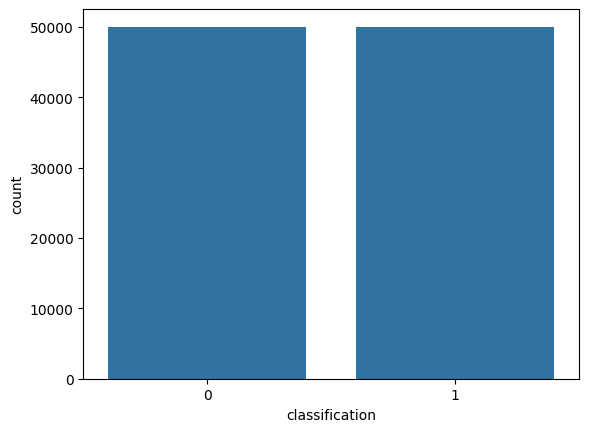

In [ ]:
sns.countplot(x=data["classification"])
plt.show()

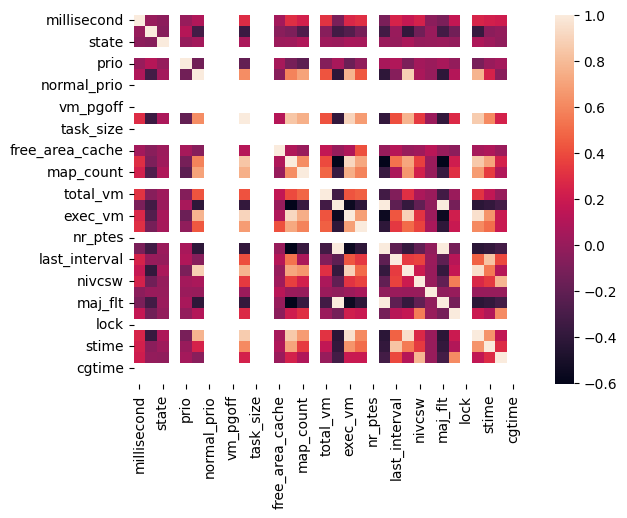

In [ ]:
corrMatrix = data.select_dtypes(include=np.number).corr()

sns.heatmap(corrMatrix, annot=False)
plt.show()

(array([ 0.5,  2.5,  4.5,  6.5,  8.5, 10.5, 12.5, 14.5, 16.5, 18.5, 20.5,
        22.5, 24.5, 26.5, 28.5, 30.5, 32.5]),
 [Text(0, 0.5, 'millisecond'),
  Text(0, 2.5, 'usage_counter'),
  Text(0, 4.5, 'static_prio'),
  Text(0, 6.5, 'policy'),
  Text(0, 8.5, 'vm_truncate_count'),
  Text(0, 10.5, 'cached_hole_size'),
  Text(0, 12.5, 'mm_users'),
  Text(0, 14.5, 'hiwater_rss'),
  Text(0, 16.5, 'shared_vm'),
  Text(0, 18.5, 'reserved_vm'),
  Text(0, 20.5, 'end_data'),
  Text(0, 22.5, 'nvcsw'),
  Text(0, 24.5, 'min_flt'),
  Text(0, 26.5, 'fs_excl_counter'),
  Text(0, 28.5, 'utime'),
  Text(0, 30.5, 'gtime'),
  Text(0, 32.5, 'signal_nvcsw')])

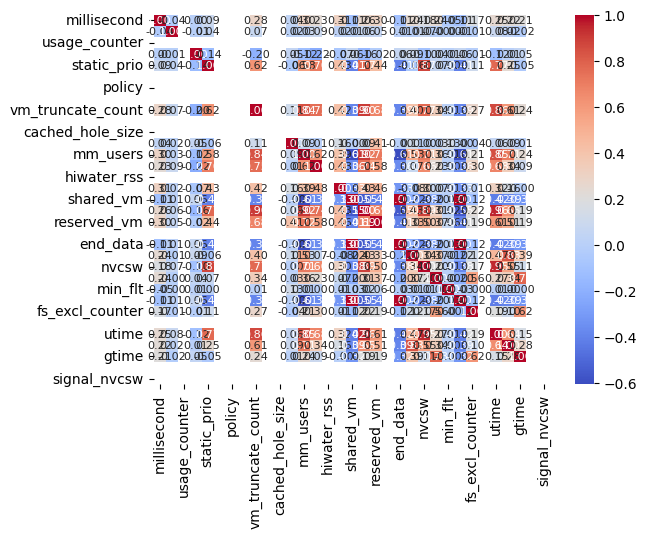

In [ ]:
# Sélectionner uniquement les colonnes numériques
corrMatrix = data.select_dtypes(include=['float64', 'int64']).corr()

# Afficher la heatmap
sns.heatmap(corrMatrix, annot=True, fmt=".2f", cmap="coolwarm", annot_kws={"size": 8})
plt.xticks(rotation=90)
plt.yticks(rotation=0)



In [ ]:
X = data.drop(["hash","classification",'vm_truncate_count','shared_vm','exec_vm','nvcsw','maj_flt','utime'],axis=1) # Préparation des données
Y = data["classification"]

In [ ]:
X.shape

(100000, 27)

In [ ]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(X,Y,test_size=0.2,random_state=1)  #diviser les données en ensembles d'entraînement et de test

In [ ]:
from sklearn.preprocessing import StandardScaler #permet de normaliser ou standardiser les caractéristiques (features) d’un dataset

scaler = StandardScaler()

In [ ]:
x_train = scaler.fit_transform(x_train) #utilise l'objet scaler (créé avec StandardScaler) pour standardiser les ensembles de données d’entraînement et de test calcule la moyenne et l'écart-type de chaque caractéristique
x_test = scaler.transform(x_test)  #et les utilise de manière à ce que chaque caractéristique ait une moyenne de 0 et une variance de 1.

In [ ]:
import tensorflow as tf    #bibliothèque pour construire et entraîner des modèles de deep learning

In [ ]:
#Nombre d'attributs
input_size = 27

#Nombre de sorties
output_size = 2

# Utiliser la même taille pour els couches cachéesse same hidden layer size for both hidden layers. Not a necessity.
hidden_layer_size = 50

# define how the model will look like
model = tf.keras.Sequential([
    tf.keras.layers.Dense(hidden_layer_size, input_shape=(input_size,), activation='relu'), # 1st hidden layer
    tf.keras.layers.Dense(hidden_layer_size, activation='relu'),
    tf.keras.layers.Dense(hidden_layer_size, activation='relu'),
    tf.keras.layers.Dense(hidden_layer_size, activation='relu'),
    tf.keras.layers.Dense(hidden_layer_size, activation='relu'),
    tf.keras.layers.Dense(hidden_layer_size, activation='relu'),
    tf.keras.layers.Dense(output_size, activation='softmax') # output layer
])

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 50)             │         1,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 50)             │         2,550 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 50)             │         2,550 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 50)             │         2,550 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 50)             │         2,550 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 50)             │         2,550 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 2)              │           102 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,252 (55.67 KB)

 Trainable params: 14,252 (55.67 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

#from keras.optimizers import SGD
#opt = SGD(lr=0.01)
#sgd = SGD(lr=0.01, decay=1e-6, momentum=0.9, nesterov=True)
#model.compile(optimizer = sgd, loss = "sparse_categorical_crossentropy", metrics=['accuracy'])

In [ ]:
# fixer la taille des batch
batch_size = 100

# fixer le nombre maximum d'epoch d'entrainement
max_epochs = 20

# set an early stopping mechanism
# let's set patience=2, to be a bit tolerant against random validation loss increases
early_stopping = tf.keras.callbacks.EarlyStopping(patience=2)

In [ ]:
result = model.fit(x=x_train,
                   y=y_train,
                   batch_size=batch_size,
                   epochs=max_epochs,
                   verbose=1,
                   callbacks=[early_stopping]
                )

Epoch 1/20
640/640 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.9016 - loss: 0.2119 - val_accuracy: 0.9985 - val_loss: 0.0051
Epoch 2/20
640/640 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9983 - loss: 0.0070 - val_accuracy: 0.9997 - val_loss: 0.0014
Epoch 3/20
640/640 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9984 - loss: 0.0056 - val_accuracy: 0.9998 - val_loss: 0.0011
Epoch 4/20
640/640 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9996 - loss: 0.0015 - val_accuracy: 0.9961 - val_loss: 0.0080
Epoch 5/20
640/640 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9992 - loss: 0.0027 - val_accuracy: 0.9991 - val_loss: 0.0015


In [ ]:
model.evaluate(x_test, y_test)

625/625 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9994 - loss: 0.0012


[0.0016556521877646446, 0.9991499781608582]

In [ ]:
import numpy as np
from sklearn.metrics import confusion_matrix, classification_report

# Probabilités (N x 2)
y_proba = model.predict(x_test)

# Classe prédite (0/1) = indice de la proba max
y_pred = np.argmax(y_proba, axis=1)

print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred, target_names=["benign", "malware"]))

625/625 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
[[10020     2]
 [   15  9963]]
              precision    recall  f1-score   support

      benign       1.00      1.00      1.00     10022
     malware       1.00      1.00      1.00      9978

    accuracy                           1.00     20000
   macro avg       1.00      1.00      1.00     20000
weighted avg       1.00      1.00      1.00     20000



In [ ]:
from sklearn.metrics import confusion_matrix, classification_report

print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred, target_names=["benign","malware"]))

[[10020     2]
 [   15  9963]]
              precision    recall  f1-score   support

      benign       1.00      1.00      1.00     10022
     malware       1.00      1.00      1.00      9978

    accuracy                           1.00     20000
   macro avg       1.00      1.00      1.00     20000
weighted avg       1.00      1.00      1.00     20000



In [ ]:
test_loss, test_accuracy = model.evaluate(x_test, y_test)

print('\nTest loss: {0:.6f}. Test accuracy: {1:.6f}%'.format(test_loss, test_accuracy*100.))

625/625 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9994 - loss: 0.0012

Test loss: 0.001656. Test accuracy: 99.914998%


In [ ]:
from keras.optimizers import SGD


sgd = SGD(learning_rate=0.001, momentum=0.9, nesterov=True)

model.compile(optimizer=sgd, loss="sparse_categorical_crossentropy", metrics=['accuracy'])


In [ ]:
result = model.fit(x=x_train,
                   y=y_train,
                   batch_size=batch_size,
                   epochs=30,
                   verbose=1,
                   initial_epoch=10, #start from epoch 11
                   callbacks=[early_stopping], #prevent overfitting
                   validation_split=0.2)

Epoch 11/30
640/640 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.9999 - loss: 5.0130e-04 - val_accuracy: 0.9999 - val_loss: 3.1947e-04
Epoch 12/30
640/640 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.9999 - loss: 4.2059e-04 - val_accuracy: 0.9999 - val_loss: 3.1343e-04
Epoch 13/30
640/640 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.9999 - loss: 3.5367e-04 - val_accuracy: 0.9999 - val_loss: 2.8612e-04
Epoch 14/30
640/640 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9999 - loss: 2.5916e-04 - val_accuracy: 0.9998 - val_loss: 3.9494e-04
Epoch 15/30
640/640 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.9999 - loss: 2.5608e-04 - val_accuracy: 0.9999 - val_loss: 2.8470e-04
Epoch 16/30
640/640 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.9999 - loss: 2.3665e-04 - val_accuracy: 0.9999 - val_loss: 2.9091e-04
Epoch 17/30
640/640 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 1.0000 - loss: 2.4470e-04 - val_accuracy: 0.9999 - val_loss: 2.6546e-04
Epoch 18/30
640/640 ━━━━━━━━━━━━━━━━━━━━ 

In [ ]:
test_loss, test_accuracy = model.evaluate(x_test, y_test)

print('\nTest loss: {0:.6f}. Test accuracy: {1:.6f}%'.format(test_loss, test_accuracy*100.))

625/625 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9998 - loss: 6.2613e-04

Test loss: 0.000776. Test accuracy: 99.980003%
